# Load the Dataset

In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('placement.csv')

# First few rows

In [3]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


# Shape (rows and columns)

In [4]:
df.shape

(100, 4)

In [5]:
# Steps
#0. Preprocess + EDA + feature selection
#1. Extract input and output cells
#2. Scale the values
#3. Train test split
#4. Train the model
#5. Evaluate the model/model selection
#6. Deploy the model

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


# Preprocessing

In [7]:
#ignores the column, doesnt delete it
df=df.iloc[:,1:]

# EDA

In [6]:
import sys
print(sys.executable)

C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\python.exe


In [7]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


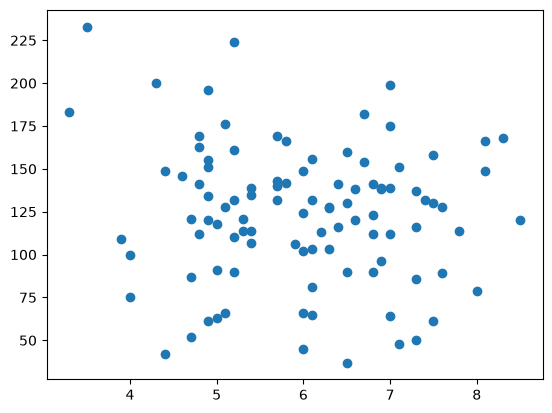

In [8]:
plt.scatter(df['cgpa'],df['iq'])

In [9]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


# Extract input and output cols

In [10]:
#independent variables
x= df.iloc[:,0:2] #2nd index is excluded
y= df.iloc[:,-1] 

In [11]:
x

,Unnamed: 0,cgpa
0,0,6.8
1,1,5.9
2,2,5.3
3,3,7.4
4,4,5.8
...,...,...
95,95,4.3
96,96,4.4
97,97,6.7
98,98,6.3


In [12]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

# Train test split

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.1, random_state=42) #this means 10% rows will now go as test set
#random_state avoids shuffling of the test state every time you run it.
#42, It comes from a joke in science fiction:In The Hitchhiker’s Guide to the Galaxy by Douglas Adams, 42 is “the Answer to the Ultimate Question of Life, the Universe, and Everything.”

In [15]:
x_train

,Unnamed: 0,cgpa
18,18,4.0
30,30,7.6
73,73,4.9
33,33,6.0
90,90,7.3
...,...,...
60,60,6.9
71,71,6.1
14,14,6.1
92,92,5.2


In [16]:
y_train

18    0
30    1
73    0
33    0
90    1
     ..
60    1
71    1
14    0
92    0
51    0
Name: placement, Length: 90, dtype: int64

# Scaling

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
scaler=StandardScaler()

In [19]:
x_train=scaler.fit_transform(x_train)

In [20]:
x_train

array([[-1.10355423e+00, -1.73718527e+00],
       [-6.90295364e-01,  1.45537303e+00],
       [ 7.90548903e-01, -9.39045697e-01],
       [-5.86980647e-01,  3.64582275e-02],
       [ 1.37599896e+00,  1.18932650e+00],
       [-1.58568957e+00, -1.40906122e-01],
       [ 8.93863619e-01, -9.39045697e-01],
       [ 9.28301858e-01,  1.18932650e+00],
       [-1.31018366e+00, -4.95634822e-01],
       [-6.55857125e-01, -1.82586745e+00],
       [ 1.70660605e-01,  1.63273738e+00],
       [ 1.30712248e+00, -1.38245657e+00],
       [-8.28048319e-01,  9.23279977e-01],
       [-2.77036498e-01,  1.45537303e+00],
       [ 6.52795948e-01,  2.25351260e+00],
       [-1.20686895e+00, -7.61681347e-01],
       [-3.45912976e-01, -9.39045697e-01],
       [ 1.58262839e+00, -1.38245657e+00],
       [-1.41349838e+00, -7.61681347e-01],
       [ 7.56110664e-01,  1.18932650e+00],
       [-1.34462190e+00,  8.34597802e-01],
       [-1.04845305e-01, -6.72999172e-01],
       [ 1.20380777e+00, -1.40906122e-01],
       [-7.

In [21]:
#fit()          → study data - calculate SD and mean and learns its distribution
#transform()    → apply rules it learns so now you apply it
#fit_transform()→ learn + apply immediately

In [22]:
x_test=scaler.transform(x_test)

In [23]:
x_test

array([[ 1.13493129,  1.36669085],
       [ 0.10178413,  2.07614825],
       [ 0.68723419,  0.30250475],
       [-0.17372178,  0.03645823],
       [-0.20816002,  1.36669085],
       [-0.38035121, -1.20509222],
       [-0.96580127, -0.9390457 ],
       [ 1.03161657, -0.9390457 ],
       [-1.37906014,  0.03645823],
       [-1.72344253,  0.74591563]])

# Train the model

In [24]:
from sklearn.linear_model import LogisticRegression
#we use LR algorithm when the output is supposed to this/that like 0 or 1 or yes or no

In [25]:
clf=LogisticRegression()
# Hey Python, prepare a logistic regression model but don’t train it yet
#clf = classifier

In [26]:
#model training
clf.fit(x_train,y_train)
# Here’s data, figure out how to predict outcomes.

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

# Evaluate 

In [27]:
y_pred=clf.predict(x_test)

In [28]:
from sklearn.metrics import accuracy_score

In [29]:
accuracy_score(y_test, y_pred)

0.8

In [30]:
!pip install mlxtend

In [31]:
import sys
print(sys.executable)

C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\python.exe


In [32]:
import sys
!{sys.executable} -m pip install mlxtend

In [33]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

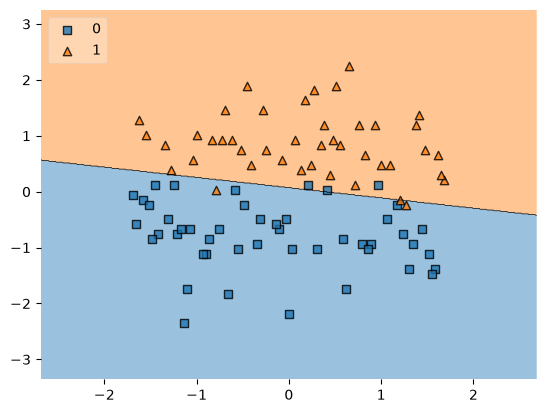

In [34]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [35]:
import pickle
#converts object into file

In [36]:
pickle.dump(clf, open('model.pkl','wb'))

In [37]:
echo "# Machine-Learning" >> README.md